In [1]:
import os
import time
import random
from PIL import Image
import shutil
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision import models

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
def set_seed(seed_value=123):
    import os, random, numpy as np, torch
    random.seed(seed_value)          # Python random
    np.random.seed(seed_value)       # NumPy random
    torch.manual_seed(seed_value)    # PyTorch CPU
    os.environ["PYTHONHASHSEED"] = str(seed_value)


    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)      # single GPU
        torch.cuda.manual_seed_all(seed_value)  # multi GPU

    # deterministic CUDA behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(123)

---
#### From 'augmented' folder save the train, val, test in 'dataset_split' folder

In [3]:
# # ---- leakage-safe split for augmented data ---
# # Keeps all versions of one image (Original + transformrd) in same split

# aug_root = "augmented"        # augmented >> (yes|no)
# out_root = "dataset_split"    # dataset_split >> train, val, test :: (yes|no)

# if os.path.exists(out_root):
#     shutil.rmtree(out_root)   # remove old split fully (otherwise can be duplicate)

# classes = ["yes", "no"]

# train_ratio = 0.8
# val_ratio = 0.1   # test will be remaining

# # ** create folders *
# for split in ["train", "val", "test"]:
#     for cls in classes:
#         os.makedirs(f"{out_root}/{split}/{cls}", exist_ok=True)

In [4]:
# # **
# for cls in classes:
#     class_path = f"{aug_root}/{cls}"
#     files = sorted(os.listdir(class_path))
#     # group files by base name before last "_"
#     groups = {}
#     for fname in files:
#         base = fname.rsplit(".", 1)[0]
#         key = base.rsplit("_", 1)[0]
#         if key not in groups:
#             groups[key] = []
#         groups[key].append(fname)

In [5]:
# groups

In [6]:
# groups.keys(), groups.items()

---

In [7]:
# ---- leakage-safe split for augmented data ---
# Keeps all versions of one image (Original + transformrd) in same split

set_seed(123)

aug_root = "augmented"        # augmented >> (yes|no)
out_root = "dataset_split"    # dataset_split >> train, val, test :: (yes|no)

if os.path.exists(out_root):
    shutil.rmtree(out_root)   # remove old split fully (otherwise can be duplicate)

classes = ["yes", "no"]

train_ratio = 0.8
val_ratio = 0.1   # test will be remaining

# ** create folders *
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(f"{out_root}/{split}/{cls}", exist_ok=True)
# **
for cls in classes:
    class_path = f"{aug_root}/{cls}"
    files = sorted(os.listdir(class_path))

    # group files by base name before last "_"
    # eg: 1-no_Affine.jpg, 1-no_ColorJitter.jpg -> group "1-no"
    groups = {}
    for fname in files:
        base = fname.rsplit(".", 1)[0]
        key = base.rsplit("_", 1)[0]
        if key not in groups:
            groups[key] = []
        groups[key].append(fname)

    keys = list(groups.keys())

    ## Shuffle group keys i.e 1-no, 2-no etc..
    random.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    split_keys = {
        "train": keys[:n_train],
        "val": keys[n_train:n_train + n_val],
        "test": keys[n_train + n_val:]
    }

    # ** copy files
    for split, klist in split_keys.items():
        for k in klist:
            for fname in groups[k]:
                src = f"{class_path}/{fname}"
                dst = f"{out_root}/{split}/{cls}/{fname}"
                shutil.copy2(src, dst)

# --- summary -
for split in ["train", "val", "test"]:
    yes_count = len(os.listdir(f"{out_root}/{split}/yes"))
    no_count = len(os.listdir(f"{out_root}/{split}/no"))
    print(f"{split:5s} -> yes: {yes_count}, no: {no_count}, total: {yes_count + no_count}")


train -> yes: 984, no: 624, total: 1608
val   -> yes: 120, no: 72, total: 192
test  -> yes: 128, no: 88, total: 216


---
#### Load the data


In [8]:
#** 
data_root = "dataset_split"   # folders: train/val/test >> yes/no
batch_size = 16
num_workers = 0
# num_epochs = 5
# lr = 1e-3

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)

Device: mps


In [9]:
## --- imqge transform -------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(data_root, "train"), transform=transform)
val_ds   = datasets.ImageFolder(os.path.join(data_root, "val"), transform=transform)
test_ds  = datasets.ImageFolder(os.path.join(data_root, "test"), transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("Classes:", train_ds.classes)
print("Train/Val/Test:", len(train_ds), len(val_ds), len(test_ds))


Classes: ['no', 'yes']
Train/Val/Test: 1608 192 216


---
#### Train  and Evaluate

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [11]:
# ** Model
## LOAD RESNET18  with imagenet weights

set_seed(123)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
## ---
model.fc = nn.Linear(model.fc.in_features, 2)  # no / yes
model = model.to(device)

criterion = nn.CrossEntropyLoss()

#**  train only classifier head

for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

best_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0
patience = 3
wait = 0

num_epochs_stage1 = 5

for epoch in range(num_epochs_stage1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"[Stage1][{epoch+1}/{num_epochs_stage1}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_wts = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping in Stage 1")
            break

## ** fine-tune whole model (small LR)

model.load_state_dict(best_wts)

for p in model.parameters():
    p.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

wait = 0
num_epochs_stage2 = 8
for epoch in range(num_epochs_stage2):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    print(f"[Stage2][{epoch+1}/{num_epochs_stage2}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_wts = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping in Stage 2")
            break

# ** Final test with best model

model.load_state_dict(best_wts)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"\nBest Val Acc: {best_val_acc:.4f}")
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


[Stage1][1/5] Train Loss: 0.4588 Acc: 0.7799 | Val Loss: 0.4350 Acc: 0.8073
[Stage1][2/5] Train Loss: 0.3252 Acc: 0.8787 | Val Loss: 0.3937 Acc: 0.7917
[Stage1][3/5] Train Loss: 0.2774 Acc: 0.8924 | Val Loss: 0.4397 Acc: 0.8125
[Stage1][4/5] Train Loss: 0.2438 Acc: 0.9061 | Val Loss: 0.3833 Acc: 0.8229
[Stage1][5/5] Train Loss: 0.2288 Acc: 0.9142 | Val Loss: 0.3728 Acc: 0.8229
[Stage2][1/8] Train Loss: 0.1241 Acc: 0.9558 | Val Loss: 0.1932 Acc: 0.9115
[Stage2][2/8] Train Loss: 0.0641 Acc: 0.9770 | Val Loss: 0.4279 Acc: 0.8385
[Stage2][3/8] Train Loss: 0.0306 Acc: 0.9913 | Val Loss: 0.6036 Acc: 0.8385
[Stage2][4/8] Train Loss: 0.0096 Acc: 0.9963 | Val Loss: 0.5219 Acc: 0.8750
Early stopping in Stage 2

Best Val Acc: 0.9115
Test Loss: 0.0398 | Test Acc: 0.9861


#### Evaluation

In [13]:
##** Load best weights
model.load_state_dict(best_wts)
model.eval()

##** Test loader from original folder
test_root = "brain_tumor_dataset"   # >>  /yes and /no

def to_rgb(img):
    return img.convert("RGB")

test_tfms = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class ImageFolderWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        path = self.samples[index][0]
        return img, target, path

test_ds = ImageFolderWithPaths(root=test_root, transform=test_tfms)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)
class_names = test_ds.classes  #  ['no', 'yes']

print("Classes:", class_names)
print("Test size:", len(test_ds))

Classes: ['no', 'yes']
Test size: 253


In [14]:
#### ** Predict
all_true, all_pred, all_paths = [], [], []

with torch.no_grad():
    for images, labels, paths in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy() ## Converts logits to predicted class index 0 or 1 

        all_pred.extend(preds.tolist())
        all_true.extend(labels.numpy().tolist())
        all_paths.extend(list(paths))

##** Metrics
acc = accuracy_score(all_true, all_pred)
print(f"\nAccuracy: {acc:.4f}\n")


Accuracy: 0.9960



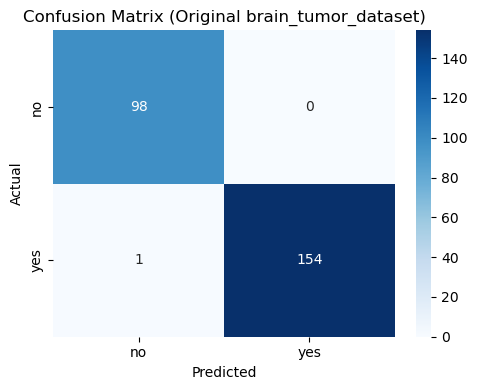

Classification Report:
              precision    recall  f1-score   support

          no     0.9899    1.0000    0.9949        98
         yes     1.0000    0.9935    0.9968       155

    accuracy                         0.9960       253
   macro avg     0.9949    0.9968    0.9958       253
weighted avg     0.9961    0.9960    0.9961       253



In [15]:
##** Plot confusion matrix
cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Original brain_tumor_dataset)")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(all_true, all_pred, target_names=class_names, digits=4))

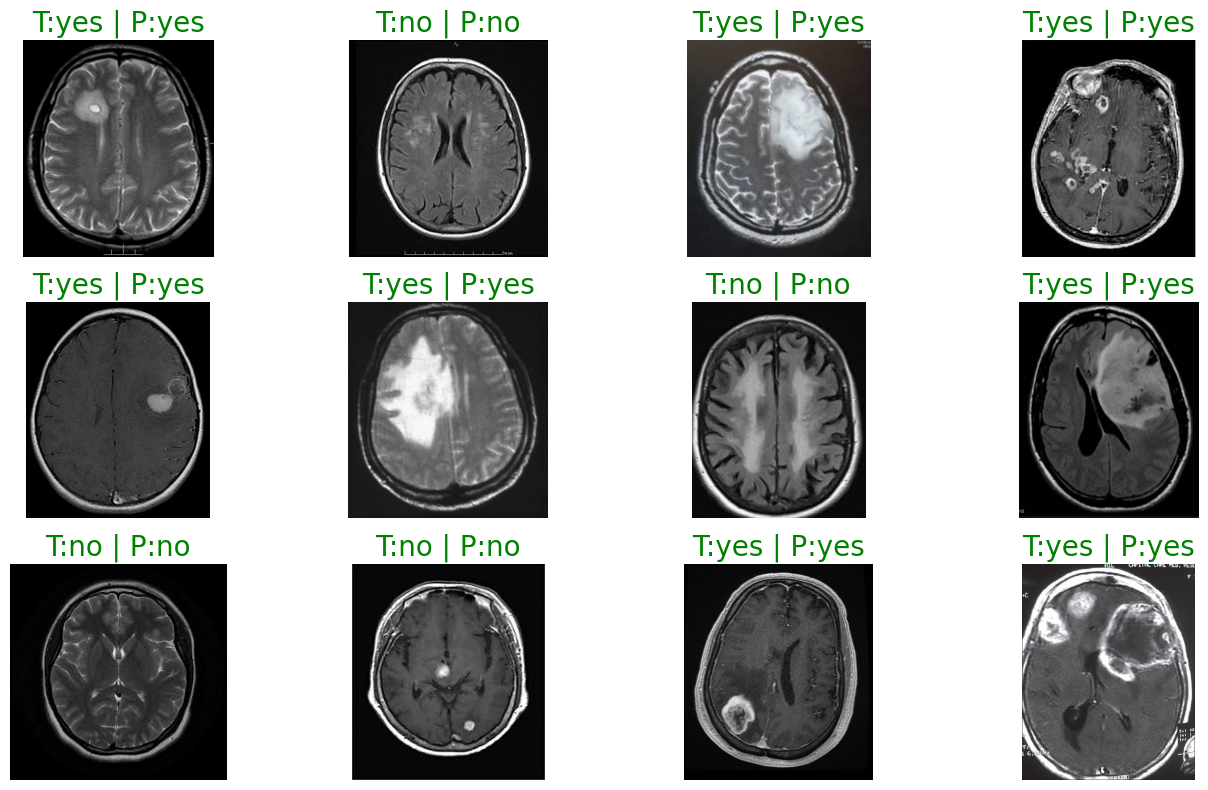

In [16]:
## &** Plot sample predictions

set_seed(123)

n_show = min(12, len(all_paths))

idxs = np.random.choice(len(all_paths), n_show, replace=False)

plt.figure(figsize=(14, 8))
for i, idx in enumerate(idxs, 1):
    img = Image.open(all_paths[idx]).convert("RGB")
    true_lbl = class_names[all_true[idx]]
    pred_lbl = class_names[all_pred[idx]]
    ok = (true_lbl == pred_lbl)

    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.title(f"T:{true_lbl} | P:{pred_lbl}", color=("green" if ok else "red"), fontsize=20)
    plt.axis("off")

plt.tight_layout()
plt.show()
